# Federated Learning: Quantization & Sparsification for Communication Efficiency
## Reducing Communication Cost via Compression

**Research Question:** How do quantization and sparsification affect FL communication efficiency?

**Independent Variables:**
- Quantization: {8, 16, 32} bits (deterministic)
- Sparsification (Top-K): {10%, 20%, 50%, 100%} of gradients

**Dependent Variables:**
- Communication cost (bits)
- Model accuracy (90% threshold)
- Convergence round
- Training time

---

## 1. Setup & Installation

In [3]:
# Check GPU
!nvidia-smi

# Install packages
!pip install torch torchvision matplotlib seaborn -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time
import copy
import json
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\n{'='*60}")
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"{'='*60}\n")

Wed Dec 10 00:36:18 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Compression Methods: Quantization & Sparsification

In [4]:
class CompressionMethod:
    """Base class for compression methods"""
    def __init__(self, name: str):
        self.name = name

    def compress(self, params: Dict) -> Tuple[Dict, int]:
        """Compress parameters and return (compressed_params, bits_used)"""
        raise NotImplementedError

    def decompress(self, compressed_params: Dict) -> Dict:
        """Decompress parameters back to full precision"""
        raise NotImplementedError


class QuantizationCompression(CompressionMethod):
    """Deterministic quantization to n bits"""
    def __init__(self, n_bits: int):
        super().__init__(f"Quantization-{n_bits}bit")
        self.n_bits = n_bits
        self.n_levels = 2 ** n_bits

    def compress(self, params: Dict) -> Tuple[Dict, int]:
        compressed = {}
        total_bits = 0

        for name, param in params.items():
            tensor = param.data

            # Find min/max for quantization range
            min_val = tensor.min()
            max_val = tensor.max()

            # Quantize to n_bits
            scale = (max_val - min_val) / (self.n_levels - 1)
            quantized = torch.round((tensor - min_val) / scale).to(torch.int32)

            # Store quantized values + metadata
            compressed[name] = {
                'quantized': quantized,
                'min': min_val,
                'max': max_val,
                'scale': scale
            }

            # Calculate bits: n_bits per parameter + overhead for min/max
            total_bits += tensor.numel() * self.n_bits + 64  # 64 bits for min/max (32 each)

        return compressed, total_bits

    def decompress(self, compressed: Dict) -> Dict:
        decompressed = {}

        for name, data in compressed.items():
            # Dequantize
            quantized = data['quantized'].float()
            scale = data['scale']
            min_val = data['min']

            decompressed[name] = quantized * scale + min_val

        return decompressed


class TopKSparsification(CompressionMethod):
    """Top-K sparsification: keep only top k% of gradients by magnitude"""
    def __init__(self, sparsity: float):
        super().__init__(f"TopK-{int(sparsity*100)}%")
        self.sparsity = sparsity  # Fraction to keep (e.g., 0.1 = keep 10%)

    def compress(self, params: Dict) -> Tuple[Dict, int]:
        compressed = {}
        total_bits = 0

        for name, param in params.items():
            tensor = param.data

            # Flatten tensor
            flat = tensor.flatten()

            # Find top-k by absolute value
            k = max(1, int(flat.numel() * self.sparsity))

            # Get top-k indices and values
            abs_flat = torch.abs(flat)
            topk_values, topk_indices = torch.topk(abs_flat, k)

            # Get actual values (with sign)
            topk_actual_values = flat[topk_indices]

            compressed[name] = {
                'values': topk_actual_values,
                'indices': topk_indices,
                'shape': tensor.shape
            }

            # Calculate bits: 32 bits per value + 32 bits per index
            total_bits += k * 32 + k * 32  # values + indices

        return compressed, total_bits

    def decompress(self, compressed: Dict) -> Dict:
        decompressed = {}

        for name, data in compressed.items():
            # Reconstruct sparse tensor
            shape = data['shape']
            values = data['values']
            indices = data['indices']

            # Create zero tensor and fill in top-k values
            tensor = torch.zeros(torch.prod(torch.tensor(shape)).item())
            tensor[indices] = values

            decompressed[name] = tensor.reshape(shape)

        return decompressed


class NoCompression(CompressionMethod):
    """Baseline: no compression (32-bit floats)"""
    def __init__(self):
        super().__init__("No-Compression")

    def compress(self, params: Dict) -> Tuple[Dict, int]:
        total_bits = 0
        for param in params.values():
            total_bits += param.numel() * 32  # 32-bit floats
        return params, total_bits

    def decompress(self, compressed: Dict) -> Dict:
        return compressed


print("✓ Compression methods defined!")

✓ Compression methods defined!


## 3. Model & FL Components

In [5]:
class SimpleCNN(nn.Module):
    """Simple CNN for MNIST"""
    def __init__(self, num_classes=10, input_channels=1):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class FederatedClient:
    """Federated Learning Client with Compression"""
    def __init__(self, client_id: int, train_data: Dataset, device: str):
        self.client_id = client_id
        self.train_data = train_data
        self.device = device
        self.model = None

    def set_model(self, model: nn.Module):
        self.model = copy.deepcopy(model).to(self.device)

    def train(self, epochs: int, batch_size: int, learning_rate: float,
              compression: CompressionMethod) -> Tuple[Dict, int, float]:
        """Train and return (compressed_params, bits_used, computation_time)"""
        self.model.train()
        optimizer = optim.SGD(self.model.parameters(), lr=learning_rate, momentum=0.9)
        criterion = nn.CrossEntropyLoss()

        train_loader = DataLoader(self.train_data, batch_size=batch_size, shuffle=True)

        total_computation_time = 0

        for epoch in range(epochs):
            epoch_start = time.time()
            for data, target in train_loader:
                data, target = data.to(self.device), target.to(self.device)
                optimizer.zero_grad()
                output = self.model(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()
            total_computation_time += time.time() - epoch_start

        # Get model parameters
        model_params = {name: param.cpu().clone() for name, param in self.model.named_parameters()}

        # Compress parameters
        compressed_params, bits_used = compression.compress(model_params)

        return compressed_params, bits_used, total_computation_time


class FederatedServer:
    """Federated Learning Server with Decompression"""
    def __init__(self, model: nn.Module, test_data: Dataset, device: str):
        self.global_model = model.to(device)
        self.test_data = test_data
        self.device = device

    def aggregate(self, compressed_params_list: List[Dict],
                  client_weights: List[float], compression: CompressionMethod):
        """Decompress and aggregate client models"""
        global_params = self.global_model.state_dict()

        # Decompress all client parameters
        decompressed_list = [compression.decompress(cp) for cp in compressed_params_list]

        # FedAvg aggregation
        for key in global_params.keys():
            if 'weight' in key or 'bias' in key:
                global_params[key] = torch.zeros_like(global_params[key])
                for client_params, weight in zip(decompressed_list, client_weights):
                    global_params[key] += client_params[key].to(self.device) * weight

        self.global_model.load_state_dict(global_params)

    def evaluate(self) -> Tuple[float, float]:
        self.global_model.eval()
        test_loader = DataLoader(self.test_data, batch_size=128, shuffle=False)

        correct = 0
        total = 0
        total_loss = 0
        criterion = nn.CrossEntropyLoss()

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.global_model(data)
                loss = criterion(outputs, target)
                total_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        avg_loss = total_loss / len(test_loader)
        return accuracy, avg_loss


def create_non_iid_split(dataset, num_clients: int, alpha: float = 0.5):
    """Create non-IID data split"""
    labels = np.array([label for _, label in dataset])
    num_classes = len(np.unique(labels))

    client_indices = [[] for _ in range(num_clients)]

    for k in range(num_classes):
        idx_k = np.where(labels == k)[0]
        np.random.shuffle(idx_k)

        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]

        idx_k_split = np.split(idx_k, proportions)
        for i, idx in enumerate(idx_k_split):
            client_indices[i].extend(idx)

    client_datasets = [Subset(dataset, indices) for indices in client_indices]

    return client_datasets

print("✓ Model and FL classes defined!")

✓ Model and FL classes defined!


## 4. Main Experiment Function

In [6]:
def run_compression_experiment(
    compression: CompressionMethod,
    num_clients: int = 10,
    num_rounds: int = 50,
    client_fraction: float = 0.3,
    local_epochs: int = 5,
    batch_size: int = 32,
    learning_rate: float = 0.01,
    target_accuracy: float = 90.0,
    alpha: float = 0.5,
    device: str = 'cuda'
) -> Dict:
    """
    Run FL experiment with specified compression method
    """
    print(f"\n{'='*60}")
    print(f"Running experiment: {compression.name}")
    print(f"{'='*60}")

    # Load MNIST dataset
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, download=True, transform=transform
    )
    train_subset_indices = np.random.choice(len(train_dataset), len(train_dataset)//10, replace=False)
    train_dataset = Subset(train_dataset, train_subset_indices)
    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, download=True, transform=transform
    )

    # Create non-IID data split
    print("Creating non-IID data split...")
    client_datasets = create_non_iid_split(train_dataset, num_clients, alpha=alpha)

    # Initialize model
    model = SimpleCNN(num_classes=10, input_channels=1)

    # Initialize server and clients
    server = FederatedServer(model, test_dataset, device)
    clients = [FederatedClient(i, client_datasets[i], device) for i in range(num_clients)]

    # Metrics tracking
    results = {
        'compression_method': compression.name,
        'accuracy_history': [],
        'loss_history': [],
        'training_time_history': [],
        'communication_cost_history': [],
        'computation_cost_history': [],
        'round_history': [],
        'convergence_round': None,
        'total_communication_cost': 0,
        'total_computation_cost': 0,
        'total_training_time': 0
    }

    cumulative_time = 0
    cumulative_comm_cost = 0
    cumulative_comp_cost = 0

    # Training loop
    for round_idx in range(num_rounds):
        round_start = time.time()

        # Sample clients
        num_selected = max(1, int(client_fraction * num_clients))
        selected_clients = np.random.choice(clients, num_selected, replace=False)

        # Client training with compression
        compressed_params_list = []
        client_weights = []
        round_comm_cost = 0
        round_comp_time = 0

        for client in selected_clients:
            client.set_model(server.global_model)

            # Train and compress
            compressed, bits_used, comp_time = client.train(
                epochs=local_epochs,
                batch_size=batch_size,
                learning_rate=learning_rate,
                compression=compression
            )

            compressed_params_list.append(compressed)
            weight = len(client.train_data) / sum(len(c.train_data) for c in selected_clients)
            client_weights.append(weight)

            # Communication cost: upload compressed model
            round_comm_cost += bits_used
            round_comp_time += comp_time

        # Server aggregation with decompression
        server.aggregate(compressed_params_list, client_weights, compression)

        # Add download cost (broadcast global model)
        # For simplicity, assume same compression for download
        _, global_model_bits = compression.compress(
            {name: param.cpu().clone() for name, param in server.global_model.named_parameters()}
        )
        round_comm_cost += global_model_bits * num_selected

        # Evaluation
        accuracy, loss = server.evaluate()

        round_time = time.time() - round_start

        # Update cumulative metrics
        cumulative_time += round_time
        cumulative_comm_cost += round_comm_cost
        cumulative_comp_cost += round_comp_time

        # Store metrics
        results['accuracy_history'].append(accuracy)
        results['loss_history'].append(loss)
        results['training_time_history'].append(cumulative_time)
        results['communication_cost_history'].append(cumulative_comm_cost)
        results['computation_cost_history'].append(cumulative_comp_cost)
        results['round_history'].append(round_idx + 1)

        # Check convergence
        if accuracy >= target_accuracy and results['convergence_round'] is None:
            results['convergence_round'] = round_idx + 1
            print(f"✓ Converged at round {round_idx + 1} with accuracy {accuracy:.2f}%")

        if (round_idx + 1) % 5 == 0 or round_idx == 0:
            print(f"Round {round_idx + 1:3d} | Acc: {accuracy:6.2f}% | Loss: {loss:.4f} | "
                  f"Time: {cumulative_time:6.1f}s | Comm: {cumulative_comm_cost/1e9:.3f}Gb")

        # Early stopping
        if results['convergence_round'] is not None and round_idx >= results['convergence_round'] + 10:
            print(f"Stopping early after convergence...")
            break

    results['total_training_time'] = cumulative_time
    results['total_communication_cost'] = cumulative_comm_cost
    results['total_computation_cost'] = cumulative_comp_cost

    print(f"\nFinal Results:")
    print(f"  Final Accuracy: {results['accuracy_history'][-1]:.2f}%")
    print(f"  Convergence Round: {results['convergence_round']}")
    print(f"  Total Training Time: {results['total_training_time']:.2f}s")
    print(f"  Total Communication Cost: {results['total_communication_cost']/1e9:.3f} Gb")
    print(f"  Total Computation Cost: {results['total_computation_cost']:.2f}s")

    return results

print("✓ Experiment function defined!")

✓ Experiment function defined!


## 5. Run All Compression Experiments

Testing:
- **Quantization**: 8, 16, 32 bits
- **Sparsification (Top-K)**: 10%, 20%, 50%, 100%

**Expected runtime on GPU: ~10-15 minutes**

In [10]:
# Define all compression methods to test
compression_methods = [
    # Baseline

    # Quantization
    QuantizationCompression(8),
    QuantizationCompression(16),
    NoCompression(),  # ← This is your 32-bit baseline

    # Sparsification (Top-K)
    TopKSparsification(0.2),   # Keep 20%
    TopKSparsification(0.5),   # Keep 50%
    TopKSparsification(1.0),   # Keep 100% (no sparsification)
]

all_results = {}

print("\n" + "="*60)
print("STARTING COMPRESSION EXPERIMENTS")
print("="*60)

for compression in compression_methods:
    results = run_compression_experiment(
        compression=compression,
        num_clients=8,
        num_rounds=100,
        client_fraction=0.3,
        local_epochs=5,
        batch_size=512,
        learning_rate=0.01,
        target_accuracy=90.0,
        alpha = 0.5,
        device=device
    )
    all_results[compression.name] = results

print("\n" + "="*60)
print("✓ ALL EXPERIMENTS COMPLETED!")
print("="*60)


STARTING COMPRESSION EXPERIMENTS

Running experiment: Quantization-8bit
Creating non-IID data split...
Round   1 | Acc:  16.12% | Loss: 2.4481 | Time:    3.4s | Comm: 0.013Gb
Round   5 | Acc:  39.65% | Loss: 2.0853 | Time:   17.6s | Comm: 0.067Gb
Round  10 | Acc:  61.10% | Loss: 1.1276 | Time:   35.6s | Comm: 0.135Gb
Round  15 | Acc:  72.46% | Loss: 0.8793 | Time:   54.6s | Comm: 0.202Gb
Round  20 | Acc:  79.22% | Loss: 0.5308 | Time:   73.3s | Comm: 0.270Gb
Round  25 | Acc:  63.41% | Loss: 1.2651 | Time:   91.3s | Comm: 0.337Gb
Round  30 | Acc:  82.46% | Loss: 0.4689 | Time:  110.4s | Comm: 0.405Gb
Round  35 | Acc:  91.18% | Loss: 0.2876 | Time:  127.9s | Comm: 0.472Gb
Round  40 | Acc:  84.81% | Loss: 0.4679 | Time:  146.3s | Comm: 0.540Gb
Round  45 | Acc:  93.70% | Loss: 0.2047 | Time:  164.6s | Comm: 0.607Gb
Round  50 | Acc:  84.67% | Loss: 0.4065 | Time:  182.9s | Comm: 0.675Gb
Round  55 | Acc:  94.00% | Loss: 0.1841 | Time:  201.2s | Comm: 0.742Gb
✓ Converged at round 59 with acc

## 6. Visualizations

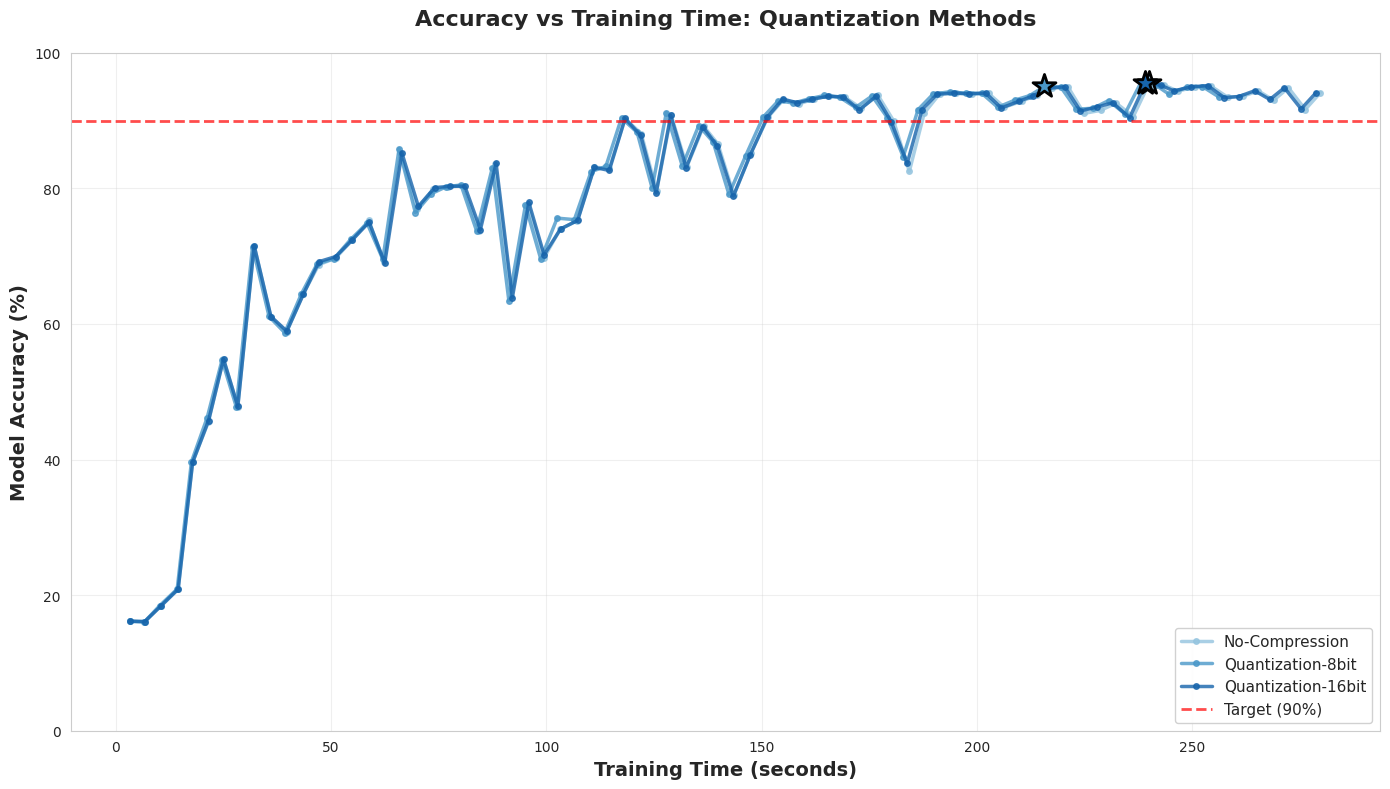

✓ Saved: accuracy_vs_time_quantization.png


In [11]:
# Plot 1: Accuracy vs Training Time (Quantization)
fig, ax = plt.subplots(figsize=(14, 8))

quant_methods = ['No-Compression', 'Quantization-8bit', 'Quantization-16bit', 'Quantization-32bit']
colors_quant = plt.cm.Blues(np.linspace(0.4, 1, len(quant_methods)))

for idx, method_name in enumerate(quant_methods):
    if method_name in all_results:
        results = all_results[method_name]
        ax.plot(results['training_time_history'], results['accuracy_history'],
               marker='o', markersize=4, linewidth=2.5,
               label=method_name, color=colors_quant[idx], alpha=0.8)

        # Mark convergence
        if results['convergence_round'] is not None:
            conv_idx = results['convergence_round'] - 1
            if conv_idx < len(results['training_time_history']):
                ax.scatter(results['training_time_history'][conv_idx],
                          results['accuracy_history'][conv_idx],
                          s=300, marker='*', color=colors_quant[idx],
                          edgecolors='black', linewidths=2, zorder=5)

ax.axhline(y=90, color='red', linestyle='--', linewidth=2,
          label='Target (90%)', alpha=0.7)

ax.set_xlabel('Training Time (seconds)', fontsize=14, fontweight='bold')
ax.set_ylabel('Model Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('Accuracy vs Training Time: Quantization Methods',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('accuracy_vs_time_quantization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: accuracy_vs_time_quantization.png")

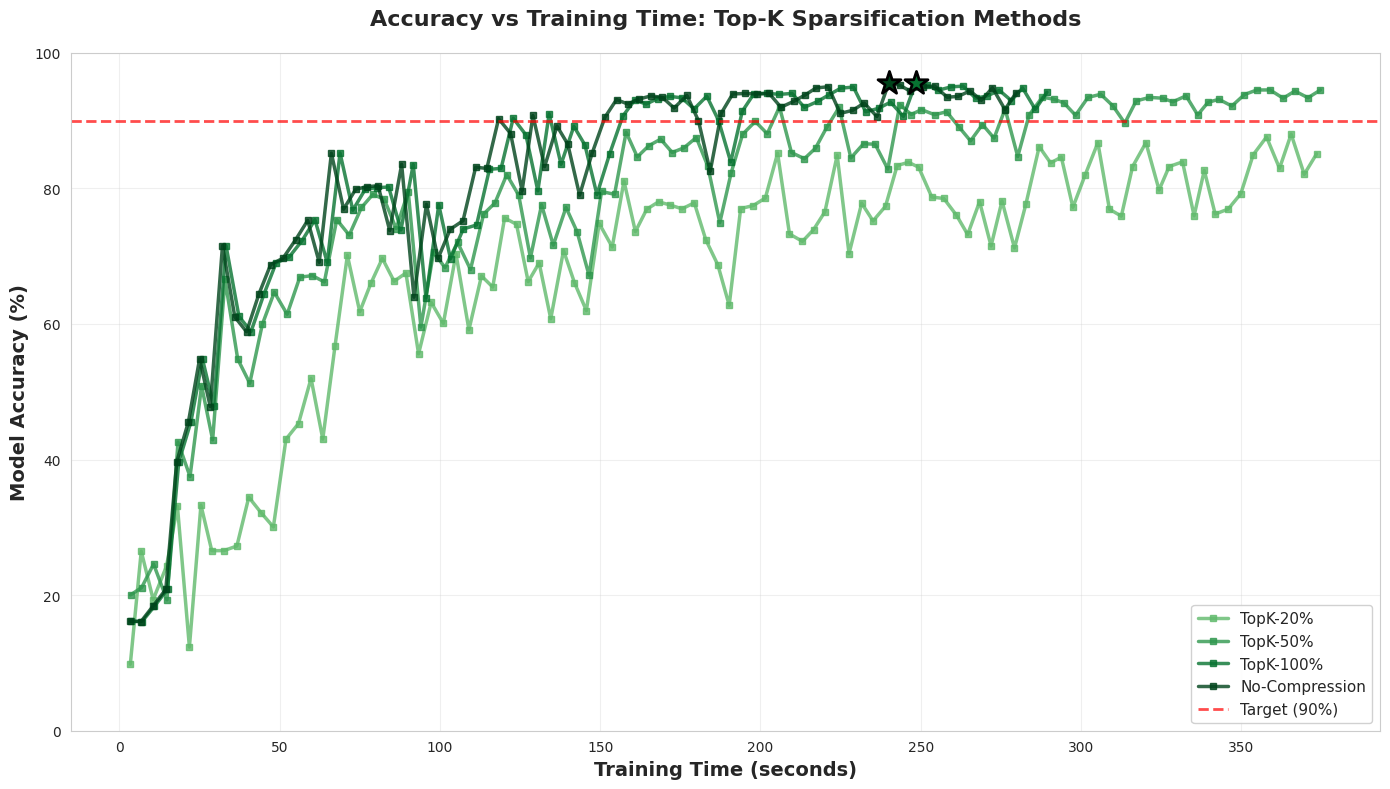

✓ Saved: accuracy_vs_time_sparsification.png


In [12]:
# Plot 2: Accuracy vs Training Time (Sparsification)
fig, ax = plt.subplots(figsize=(14, 8))

sparse_methods = ['TopK-10%', 'TopK-20%', 'TopK-50%', 'TopK-100%', 'No-Compression']
colors_sparse = plt.cm.Greens(np.linspace(0.4, 1, len(sparse_methods)))

for idx, method_name in enumerate(sparse_methods):
    if method_name in all_results:
        results = all_results[method_name]
        ax.plot(results['training_time_history'], results['accuracy_history'],
               marker='s', markersize=4, linewidth=2.5,
               label=method_name, color=colors_sparse[idx], alpha=0.8)

        # Mark convergence
        if results['convergence_round'] is not None:
            conv_idx = results['convergence_round'] - 1
            if conv_idx < len(results['training_time_history']):
                ax.scatter(results['training_time_history'][conv_idx],
                          results['accuracy_history'][conv_idx],
                          s=300, marker='*', color=colors_sparse[idx],
                          edgecolors='black', linewidths=2, zorder=5)

ax.axhline(y=90, color='red', linestyle='--', linewidth=2,
          label='Target (90%)', alpha=0.7)

ax.set_xlabel('Training Time (seconds)', fontsize=14, fontweight='bold')
ax.set_ylabel('Model Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('Accuracy vs Training Time: Top-K Sparsification Methods',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('accuracy_vs_time_sparsification.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: accuracy_vs_time_sparsification.png")

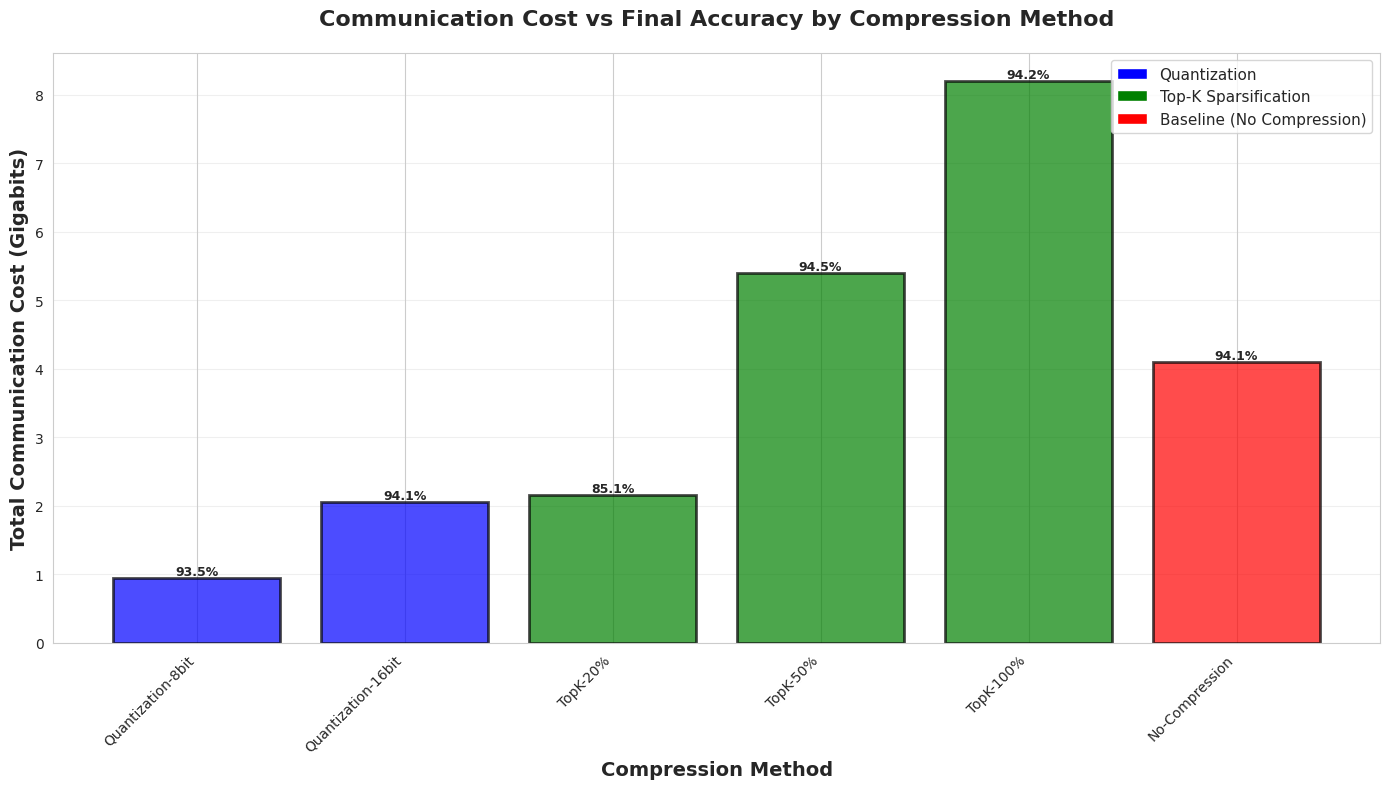

✓ Saved: communication_cost_comparison.png


In [13]:
# Plot 3: Communication Cost Comparison
fig, ax = plt.subplots(figsize=(14, 8))

methods = []
comm_costs = []
final_accs = []
colors_all = []

# Quantization methods
for method in ['Quantization-8bit', 'Quantization-16bit', 'Quantization-32bit']:
    if method in all_results:
        methods.append(method)
        comm_costs.append(all_results[method]['total_communication_cost'] / 1e9)
        final_accs.append(all_results[method]['accuracy_history'][-1])
        colors_all.append('blue')

# Sparsification methods
for method in ['TopK-10%', 'TopK-20%', 'TopK-50%', 'TopK-100%']:
    if method in all_results:
        methods.append(method)
        comm_costs.append(all_results[method]['total_communication_cost'] / 1e9)
        final_accs.append(all_results[method]['accuracy_history'][-1])
        colors_all.append('green')

# Baseline
if 'No-Compression' in all_results:
    methods.append('No-Compression')
    comm_costs.append(all_results['No-Compression']['total_communication_cost'] / 1e9)
    final_accs.append(all_results['No-Compression']['accuracy_history'][-1])
    colors_all.append('red')

# Create bar plot
x = np.arange(len(methods))
bars = ax.bar(x, comm_costs, color=colors_all, alpha=0.7, edgecolor='black', linewidth=2)

# Add accuracy labels on bars
for i, (bar, acc) in enumerate(zip(bars, final_accs)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{acc:.1f}%',
           ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Compression Method', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Communication Cost (Gigabits)', fontsize=14, fontweight='bold')
ax.set_title('Communication Cost vs Final Accuracy by Compression Method',
            fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Quantization'),
    Patch(facecolor='green', label='Top-K Sparsification'),
    Patch(facecolor='red', label='Baseline (No Compression)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('communication_cost_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: communication_cost_comparison.png")

## 7. Summary Table

In [14]:
print("\n" + "="*100)
print("SUMMARY TABLE: Compression Methods Comparison")
print("="*100)
print(f"{'Method':<25} {'Conv. Round':<15} {'Time (s)':<12} {'Comm (Gb)':<12} {'Final Acc (%)':<15}")
print("-"*100)

# Sort by method type
method_order = [
    'No-Compression',
    'Quantization-8bit', 'Quantization-16bit', 'Quantization-32bit',
    'TopK-10%', 'TopK-20%', 'TopK-50%', 'TopK-100%'
]

for method_name in method_order:
    if method_name in all_results:
        results = all_results[method_name]
        conv = results['convergence_round'] if results['convergence_round'] else 'N/A'
        time = f"{results['total_training_time']:.1f}"
        comm = f"{results['total_communication_cost']/1e9:.3f}"
        acc = f"{results['accuracy_history'][-1]:.2f}"

        print(f"{method_name:<25} {str(conv):<15} {time:<12} {comm:<12} {acc:<15}")

print("="*100)

# Calculate compression ratios
if 'No-Compression' in all_results:
    baseline_comm = all_results['No-Compression']['total_communication_cost']
    print("\nCompression Ratios (vs No Compression):")
    print("-"*100)
    for method_name in method_order[1:]:
        if method_name in all_results:
            method_comm = all_results[method_name]['total_communication_cost']
            ratio = baseline_comm / method_comm if method_comm > 0 else float('inf')
            savings = (1 - method_comm / baseline_comm) * 100 if baseline_comm > 0 else 0
            print(f"{method_name:<25} Ratio: {ratio:.2f}x | Savings: {savings:.1f}%")
    print("="*100)



SUMMARY TABLE: Compression Methods Comparison
Method                    Conv. Round     Time (s)     Comm (Gb)    Final Acc (%)  
----------------------------------------------------------------------------------------------------
No-Compression            65              279.8        4.102        94.13          
Quantization-8bit         59              256.2        0.945        93.47          
Quantization-16bit        65              278.8        2.051        94.13          
TopK-20%                  N/A             373.5        2.159        85.10          
TopK-50%                  N/A             374.7        5.397        94.52          
TopK-100%                 65              289.4        8.203        94.18          

Compression Ratios (vs No Compression):
----------------------------------------------------------------------------------------------------
Quantization-8bit         Ratio: 4.34x | Savings: 77.0%
Quantization-16bit        Ratio: 2.00x | Savings: 50.0%
TopK-20%  

## 8. Save Results

In [15]:
# Save all results to JSON
with open('compression_results.json', 'w') as f:
    json_results = {}
    for key, results in all_results.items():
        json_results[key] = {
            k: [float(v) if isinstance(v, (np.floating, np.integer)) else v
                for v in val] if isinstance(val, list) else val
            for k, val in results.items()
        }
    json.dump(json_results, f, indent=2)

print("✓ Results saved to 'compression_results.json'")
print("✓ Plots saved:")
print("  - accuracy_vs_time_quantization.png")
print("  - accuracy_vs_time_sparsification.png")
print("  - communication_cost_comparison.png")
print("\nDownload files from the left sidebar!")

# Optional: Save to Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# !cp *.png *.json /content/drive/MyDrive/

✓ Results saved to 'compression_results.json'
✓ Plots saved:
  - accuracy_vs_time_quantization.png
  - accuracy_vs_time_sparsification.png
  - communication_cost_comparison.png

Download files from the left sidebar!
